In [ ]:
pip install pandas sqlalchemy pymysql scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00


In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

# Credentials
username = "dm_team3"
password = quote_plus("DM!$!Team!27@9!20&")  # IMPORTANT
host = "18.136.157.135"
database = "project_telecom"

# Create engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:3306/{database}"
)

# Test connection
df = pd.read_sql("SELECT 1", engine)
print(df)

   1
0  1


In [ ]:
pd.read_sql("SHOW TABLES", engine)

,Tables_in_project_telecom
0,telecom_churn_data


In [ ]:
query = "SELECT * FROM telecom_churn_data"
data = pd.read_sql(query, engine)

print(data.shape)
data.head()

(243553, 14)


,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [ ]:
data.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [ ]:
data.drop("customer_id",axis=1,inplace=True)

In [ ]:
data.drop("pincode",axis=1,inplace=True)

In [ ]:
import pandas as pd
data['date_of_registration'] = pd.to_datetime(data['date_of_registration'])
today = pd.to_datetime("today")
data['tenure_days'] = (today - data['date_of_registration']).dt.days

print(data[['date_of_registration', 'tenure_days']].head())

  date_of_registration  tenure_days
0           2020-01-01         2290
1           2020-01-01         2290
2           2020-01-01         2290
3           2020-01-01         2290
4           2020-01-01         2290


In [ ]:
data.head()

,telecom_partner,gender,age,state,city,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_days
0,Reliance Jio,F,25,Karnataka,Kolkata,2020-01-01,4,124962,44,45,-361,0,2290
1,Reliance Jio,F,55,Mizoram,Mumbai,2020-01-01,2,130556,62,39,5973,0,2290
2,Vodafone,F,57,Arunachal Pradesh,Delhi,2020-01-01,0,148828,49,24,193,1,2290
3,BSNL,M,46,Tamil Nadu,Kolkata,2020-01-01,1,38722,80,25,9377,1,2290
4,BSNL,F,26,Tripura,Delhi,2020-01-01,2,55098,78,15,1393,0,2290


In [ ]:
data.drop('date_of_registration',axis=1,inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   telecom_partner   243553 non-null  object
 1   gender            243553 non-null  object
 2   age               243553 non-null  int64 
 3   state             243553 non-null  object
 4   city              243553 non-null  object
 5   num_dependents    243553 non-null  int64 
 6   estimated_salary  243553 non-null  int64 
 7   calls_made        243553 non-null  int64 
 8   sms_sent          243553 non-null  int64 
 9   data_used         243553 non-null  int64 
 10  churn             243553 non-null  int64 
 11  tenure_days       243553 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 22.3+ MB


In [ ]:
data.describe(include='all')

,telecom_partner,gender,age,state,city,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_days
count,243553,243553,243553.000000,243553,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
unique,4,2,NaN,28,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Reliance Jio,M,NaN,Uttarakhand,Chennai,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,61123,145977,NaN,8856,40749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,46.077609,NaN,NaN,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478,1680.999996
std,NaN,NaN,16.444029,NaN,NaN,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359,351.897027
min,NaN,NaN,18.000000,NaN,NaN,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000,1071.000000
25%,NaN,NaN,32.000000,NaN,NaN,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000,1376.000000
50%,NaN,NaN,46.000000,NaN,NaN,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000,1681.000000
75%,NaN,NaN,60.000000,NaN,NaN,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000,1986.000000


In [ ]:
data=pd.get_dummies(data,columns=['telecom_partner','gender'],drop_first=True)

In [ ]:
freq=data['state'].value_counts()/len(data)
data['state']=data['state'].map(freq)

In [ ]:
freq=data['city'].value_counts()/len(data)
data['city']=data['city'].map(freq)

In [ ]:
data.head(10)

,age,state,city,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,tenure_days,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,gender_M
0,25,0.036317,0.166949,4,124962,44,45,-361,0,2290,False,True,False,False
1,55,0.035676,0.165820,2,130556,62,39,5973,0,2290,False,True,False,False
2,57,0.035955,0.166108,0,148828,49,24,193,1,2290,False,False,True,False
3,46,0.035795,0.166949,1,38722,80,25,9377,1,2290,True,False,False,True
4,26,0.035557,0.166108,2,55098,78,15,1393,0,2290,True,False,False,False
5,36,0.036362,0.167311,1,73452,91,24,8109,0,2290,False,False,True,True
6,60,0.036317,0.166108,1,110035,36,13,8512,0,2290,True,False,False,False
7,46,0.035955,0.166949,4,104541,87,40,2245,1,2290,True,False,False,True
8,53,0.035647,0.165820,2,79439,34,12,10039,0,2290,False,True,False,False
9,57,0.035926,0.165820,0,126422,61,33,567,0,2290,True,False,False,False


In [ ]:
import matplotlib.pyplot as plt
figure = plt.figure(figsize=(20,25), facecolor='white')

<Figure size 2000x2500 with 0 Axes>

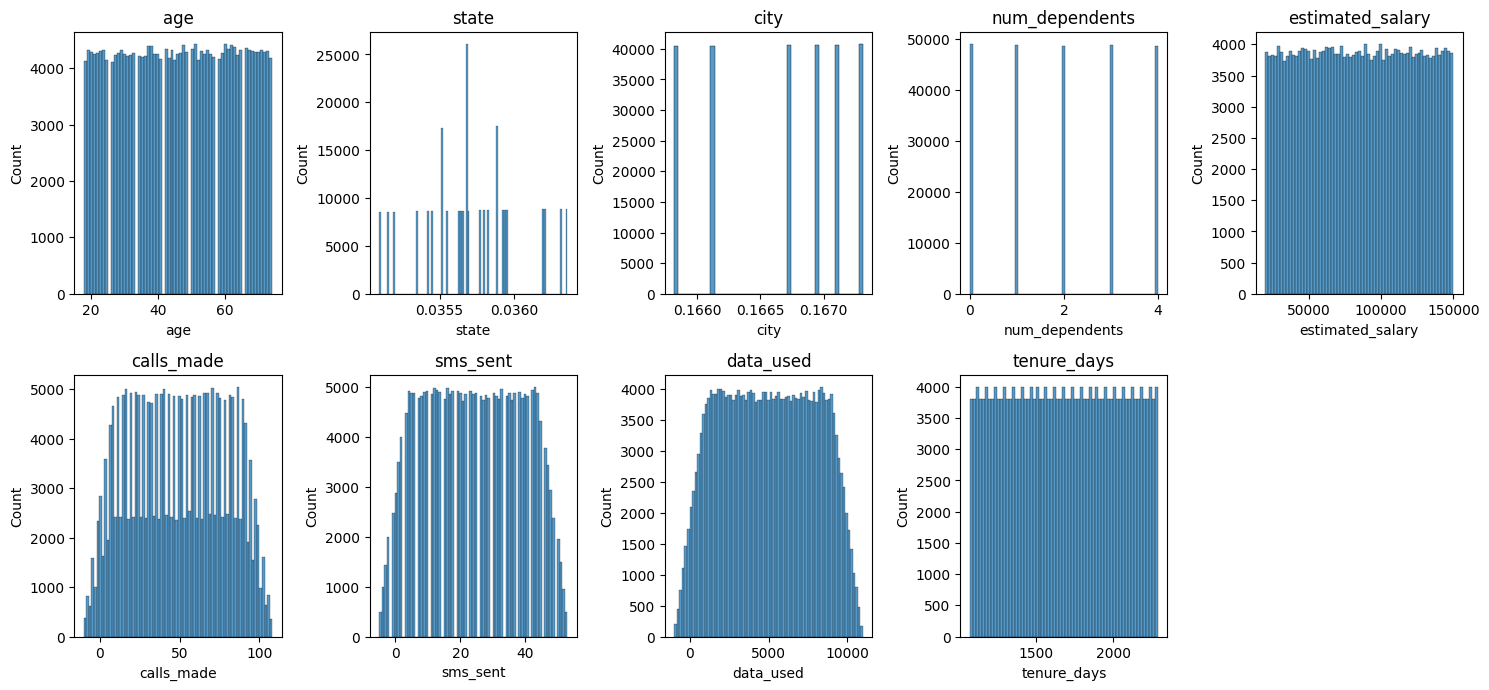

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
num_cols = data.select_dtypes(include=[np.number]).columns
num_cols = [col for col in num_cols if col != 'churn']
plt.figure(figsize=(15, 10))
plot_number = 1

for col in num_cols:
    if plot_number <= 15:
        plt.subplot(3, 5, plot_number)
        sns.histplot(x=data[col])
        plt.title(col)
        plot_number += 1

plt.tight_layout()
plt.show()

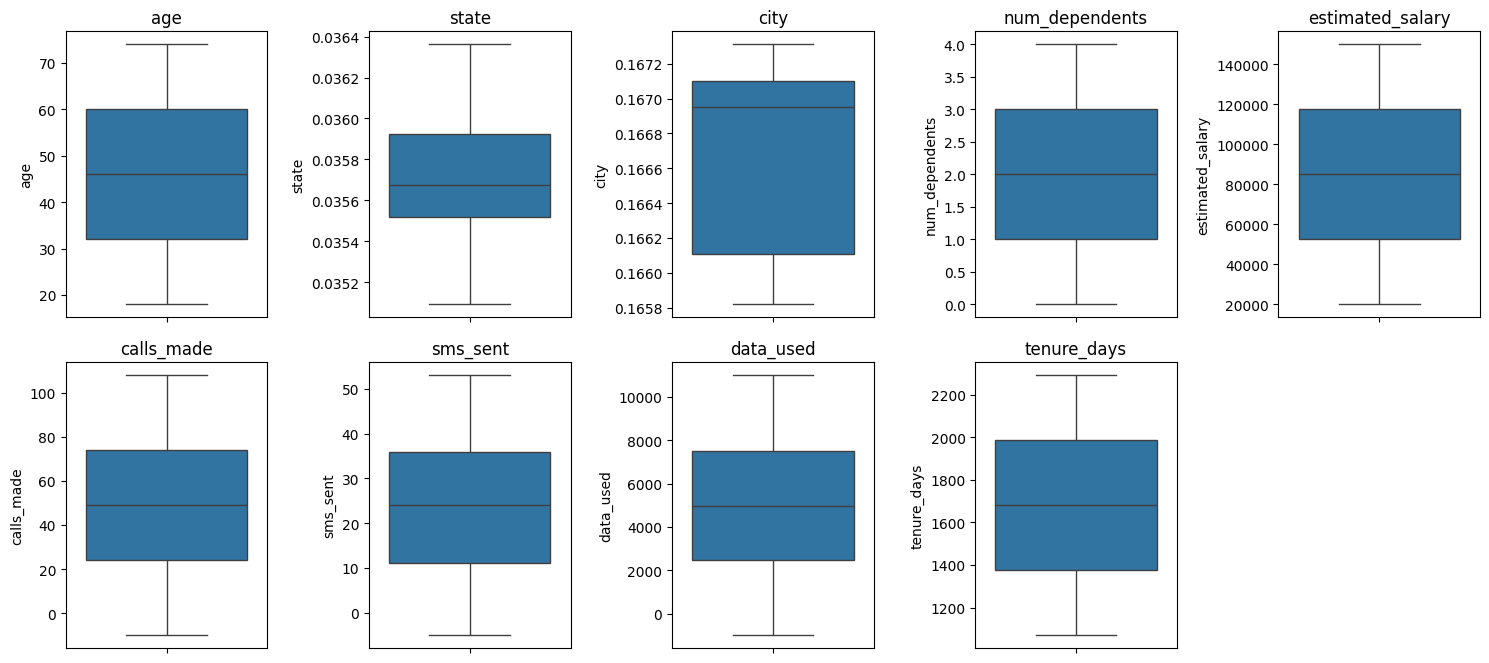

In [ ]:

import numpy as np
num_cols = data.select_dtypes(include=[np.number]).columns
num_cols = [col for col in num_cols if col != 'churn']

plt.figure(figsize=(15, 10))
plot_number = 1

for col in num_cols:
    if plot_number <= 15:
        plt.subplot(3, 5, plot_number)
        sns.boxplot(y=data[col])
        plt.title(col)
        plot_number += 1

plt.tight_layout()
plt.show()

In [ ]:
data.columns

Index(['age', 'state', 'city', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn', 'tenure_days',
       'telecom_partner_BSNL', 'telecom_partner_Reliance Jio',
       'telecom_partner_Vodafone', 'gender_M'],
      dtype='object')

In [ ]:
x=data.drop('churn',axis=1)
y=data['churn']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
cols_to_scale=['age','num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used','tenure_days']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler only on selected columns
x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

In [ ]:
x_train.head()

,age,state,city,num_dependents,estimated_salary,calls_made,sms_sent,data_used,tenure_days,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,gender_M
118890,-0.733871,0.036317,0.165820,-0.705320,-0.087684,0.305406,0.410322,-1.021991,0.037511,False,False,True,True
173694,1.515194,0.035894,0.166108,0.708244,0.435315,-0.373917,0.206791,1.361428,-0.740656,False,True,False,False
28678,-0.551514,0.035926,0.166108,0.708244,0.312339,1.290423,-0.675177,1.045610,1.321203,False,True,False,True
187320,1.211266,0.035446,0.166711,0.708244,1.592457,0.882830,0.003260,-1.157633,-0.933778,False,True,False,True
101172,1.636765,0.035676,0.167101,0.708244,-0.513049,-0.713578,-0.946552,-0.652801,0.290274,False,True,False,False


In [ ]:
x_test.head()

,age,state,city,num_dependents,estimated_salary,calls_made,sms_sent,data_used,tenure_days,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,gender_M
230796,-1.584869,0.035795,0.166108,0.001462,0.524715,-0.373917,1.563665,-1.124657,-1.552904,False,False,False,True
191985,1.332837,0.036362,0.166108,0.001462,-0.355859,-0.204086,0.613853,-1.361266,-0.999099,False,False,True,False
18778,-0.977013,0.035697,0.165820,1.415026,1.396629,-1.732562,-0.810864,0.614548,1.463205,False,False,True,True
241016,-1.463298,0.036202,0.167311,-1.412102,-0.714553,-0.577713,-0.878708,-0.735410,-1.697745,False,False,True,True
136494,1.028909,0.035557,0.166711,1.415026,-0.301659,0.645067,-0.878708,0.129094,-0.212411,False,True,False,True


In [ ]:
y_train.head()

,churn
118890,1
173694,0
28678,0
187320,0
101172,0


In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_sm,y_sm)

LogisticRegression()

In [ ]:
y_sm.value_counts()

,count
churn,
1,155798
0,155798


In [ ]:
data.churn.value_counts()

,count
churn,
0,194726
1,48827


In [ ]:
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_sm,y_sm=smote.fit_resample(x_train,y_train)

In [ ]:
from sklearn.metrics import f1_score,accuracy_score,classification_report
y_pred=model.predict(x_test)
report1=classification_report(y_test,y_pred)
print(report1)

              precision    recall  f1-score   support

           0       0.80      0.50      0.61     38928
           1       0.20      0.49      0.28      9783

    accuracy                           0.50     48711
   macro avg       0.50      0.50      0.45     48711
weighted avg       0.68      0.50      0.55     48711



In [ ]:
from sklearn.tree import DecisionTreeClassifier
model2=DecisionTreeClassifier()
model2.fit(x_sm,y_sm)
y_pred2=model2.predict(x_test)
report2=classification_report(y_test,y_pred2)
print(report2)

              precision    recall  f1-score   support

           0       0.80      0.78      0.79     38928
           1       0.21      0.23      0.22      9783

    accuracy                           0.67     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.67      0.67     48711



In [ ]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier()
model3.fit(x_sm,y_sm)
y_pred3=model3.predict(x_test)
report3=classification_report(y_test,y_pred3)
print(report3)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.22      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.51      0.50      0.45     48711
weighted avg       0.68      0.80      0.71     48711



In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBClassifier
model4=XGBClassifier()
model4.fit(x_sm,y_sm)
y_pred4=model4.predict(x_test)
report4=classification_report(y_test,y_pred4)
print(report4)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.31      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.56      0.50      0.44     48711
weighted avg       0.70      0.80      0.71     48711



In [ ]:
param_grid={'n_estimator':[100,200,300,400,500],
            'learning_rate':[0.01,0.05,0.1],
            'min_child_weight':[5,6,7,8],
            'gamma':[0,0.01,0.2]}


In [ ]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(model4,param_grid,verbose=1,scoring='f1',cv=3)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
grid.fit(x_sm,y_sm)

Fitting 3 folds for each of 180 candidates, totalling 540 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'gamma': [0, 0.01, 0.2],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'min_child_weight': [5, 6, 7, 8],
                         'n_estimator': [100, 200, 300, 400, 500]},
             scoring='f1', verbose=1)

In [ ]:
print(grid.best_params_)

{'gamma': 0, 'learning_rate': 0.1, 'min_child_weight': 6, 'n_estimator': 100}


In [ ]:
model5=XGBClassifier(gamma=0,learning_rate=0.1,min_child_weight=6,n_estimator=100)
model5.fit(x_sm,y_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=6, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimator=100,
              n_estimators=None, n_jobs=None, ...)

In [ ]:
y_pred5=model5.predict(x_test)
report5=classification_report(y_test,y_pred5)
print(report5)

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38928
           1       0.00      0.00      0.00      9783

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



 99%|===================| 48440/48711 [01:26<00:00]       

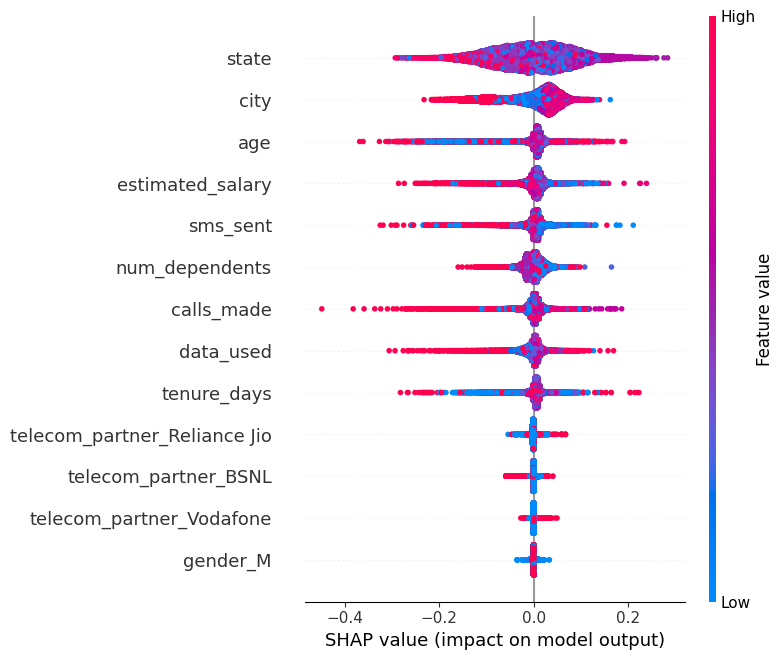

In [ ]:
import shap

# Identify boolean columns that need conversion
boolean_cols = ['telecom_partner_BSNL', 'telecom_partner_Reliance Jio', 'telecom_partner_Vodafone', 'gender_M']

# Convert boolean columns in x_test to integer type (0 or 1)
for col in boolean_cols:
    x_test[col] = x_test[col].astype(int)

explainer=shap.Explainer(model5,x_test)
shap_values=explainer(x_test)
shap.summary_plot(shap_values,x_test)